# Face Image Analysis and Reconstruction using PCA (Eigenfaces)

This notebook demonstrates the application of PCA to facial image analysis using
the Olivetti faces dataset. It shows how faces can be decomposed into and
reconstructed from eigenfaces (principal components of face images).

The Olivetti dataset contains 400 64x64 grayscale images of faces.
The notebook shows:
1. Original face visualization
2. Top eigenfaces extraction
3. Face reconstruction using eigenfaces

## Loading the Dataset

The Olivetti dataset contains 400 grayscale face images from 40 subjects (10 images each),
each stored as a flat vector of 4,096 pixel values (64×64).

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# Load the Olivetti faces dataset
faces, target = fetch_olivetti_faces(return_X_y=True)
print("Faces data shape:", faces.shape)  # Should show (400 faces, 4096 pixels each)

Faces data shape: (400, 4096)


## Visualising a Sample Face

Each sample is a flat vector of 4,096 values. Reshaping it to 64×64 gives the original image.

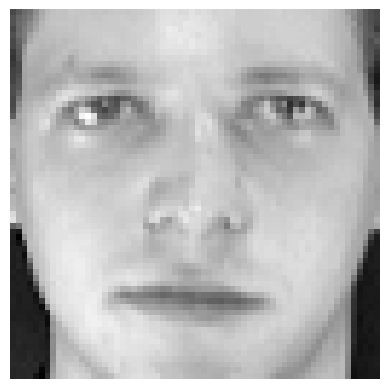

In [2]:
# Display first face
plt.imshow(faces[0].reshape(64,64), cmap='gray')
plt.axis('off')
plt.show()

## Extracting Eigenfaces with PCA

PCA on the face matrix produces **eigenfaces** — the principal directions of variation across
all faces. The `explained_variance_` tells us how much of the total variation each eigenface captures.

In [3]:
# Perform PCA to extract eigenfaces
pca = PCA() 
pca.fit(faces)

eigenfaces = pca.components_  # Shape (n_components, n_features): each ROW is an eigenface (right singular vector V)
explained_variance = pca.explained_variance_  # Eigenvalues of the covariance matrix (σ², not singular values σ)

## Visualising the Top 10 Eigenfaces

The first eigenfaces capture global variations (lighting, pose), while later ones represent
finer details. The title of each subplot shows its explained variance.

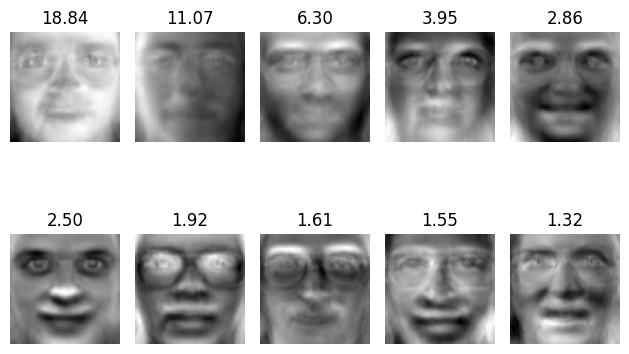

In [4]:
# Visualize top 10 eigenfaces with their explained variance
fig, ax = plt.subplots(2,5)
ax = ax.flatten() # Flatten the 2D array to 1D, for easier indexing

for idx in range(10):
    ax[idx].imshow(eigenfaces[idx].reshape(64,64), cmap='gray')
    ax[idx].set_title(f"{explained_variance[idx]:.2f}")
    ax[idx].axis('off')

plt.tight_layout()
plt.show()

## Reconstructing a Face from Eigenfaces

Any face can be approximated by projecting it onto the first N eigenfaces and summing the
weighted contributions. With enough eigenfaces the reconstruction is nearly indistinguishable
from the original.

The reconstruction follows the SVD analogy **B = USVᵀ** where **B** is the *mean-centred* data:
1. **Centre** the face by subtracting the mean face (`pca.mean_`)
2. **Project** onto the first N eigenfaces → coefficients (analogous to the row of **U** scaled by **S**)
3. **Reconstruct** by multiplying back through the eigenfaces and **adding the mean back**

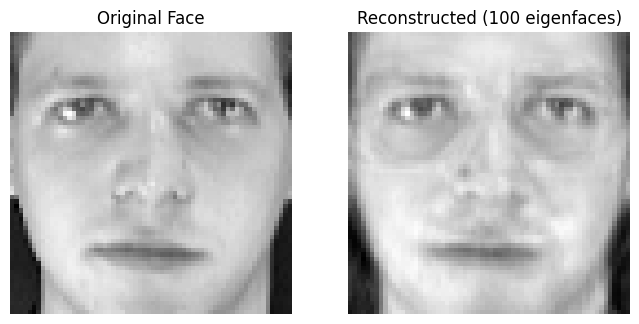

In [5]:
# Reconstruct a face using first n eigenfaces
n_eigenfaces = 100

mean_face = pca.mean_  # The mean face subtracted during PCA fitting

# Step 1: centre the face (analogous to working with B = X - mean in SVD)
face_centred = faces[0] - mean_face

# Step 2: project onto eigenfaces to get coefficients (analogous to U * S)
project_coeff = face_centred @ eigenfaces.T

# Step 3: reconstruct — multiply coefficients back through eigenfaces, then add the mean back
reconstructed_face = project_coeff[:n_eigenfaces] @ eigenfaces[:n_eigenfaces] + mean_face

# Compare original and reconstructed face
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(faces[0].reshape(64,64), cmap='gray')
ax[0].set_title('Original Face')
ax[0].axis('off')

ax[1].imshow(reconstructed_face.reshape(64,64), cmap='gray')
ax[1].set_title(f'Reconstructed ({n_eigenfaces} eigenfaces)')
ax[1].axis('off')
plt.show()